In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import silhouette_score

In [22]:
df = pd.read_csv('Customers-2.csv')
df.head()

,Age,Annual Income,Spending Score
0,19,15000,39
1,21,15000,81
2,20,16000,6
3,23,16000,77
4,31,17000,40


In [23]:
# summary statistics
df.describe()

,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000
mean,38.850000,60655.000000,50.200000
std,13.969007,26465.602498,25.823522
min,18.000000,15000.000000,1.000000
25%,28.750000,41500.000000,34.750000
50%,36.000000,61500.000000,50.000000
75%,49.000000,78000.000000,73.000000
max,70.000000,137000.000000,99.000000


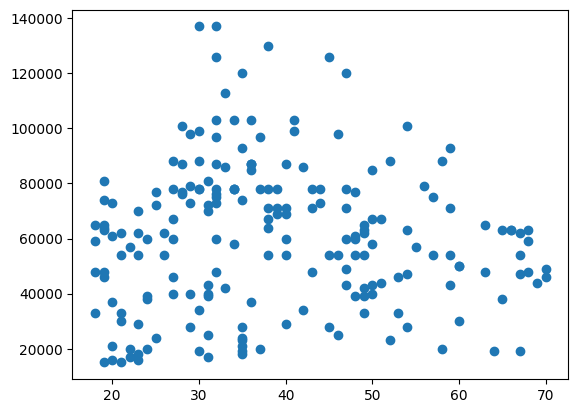

In [24]:
#scatter
fig, ax = plt.subplots()
ax.scatter('Age', 'Annual Income', data=df)

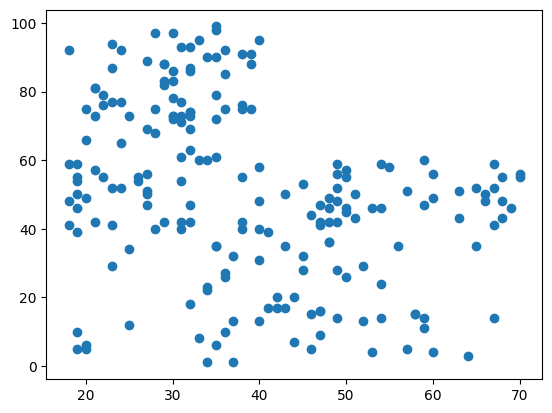

In [25]:
#scatter
fig, ax = plt.subplots()
ax.scatter('Age', 'Spending Score', data=df)

In [26]:
df

,Age,Annual Income,Spending Score
0,19,15000,39
1,21,15000,81
2,20,16000,6
3,23,16000,77
4,31,17000,40
...,...,...,...
195,35,120000,79
196,45,126000,28
197,32,126000,74
198,32,137000,18


In [27]:
# Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(df)

    score = silhouette_score(df, clusters)
    results.append([k, score])

results_df = pd.DataFrame(results, columns=["K", "Silhouette Score"])
results_df

,K,Silhouette Score
0,2,0.541927
1,3,0.517193
2,4,0.547176
3,5,0.569997
4,6,0.590410
5,7,0.554999
6,8,0.554631


In [28]:
# Cluster Count
kmeans = KMeans(n_clusters=6, random_state=42)

df["Cluster"] = kmeans.fit_predict(df)
cluster_counts = (df["Cluster"].value_counts().sort_index().reset_index())

cluster_counts.columns = ["Cluster", "Customers"]
cluster_counts

,Cluster,Customers
0,0,50
1,1,14
2,2,32
3,3,54
4,4,8
5,5,42


In [29]:
pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.columns[:-1]
)

,Age,Annual Income,Spending Score
0,41.520000,60460.000000,50.060000
1,38.142857,99142.857143,53.357143
2,34.906250,22000.000000,49.656250
3,36.018519,78388.888889,49.555556
4,36.500000,126125.000000,49.625000
5,43.000000,42238.095238,50.666667
